[Table of Contents](./table_of_contents.ipynb)

# Discrete Bayes Filter

In [1]:
from __future__ import division, print_function
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

卡尔曼滤波器属于一个称为*贝叶斯滤波器*的滤波器类别。大多数教科书中对卡尔曼滤波器的介绍时都给出了贝叶斯公式，这些公式虽然说明了它是如何推导出卡尔曼滤波方程，但大多数的讨论都处于一个非常抽象的水平上。

想要彻底掌握这些公式需要对数学的几个领域有一个相当复杂的理解，它仍然会留下许多需要理解的工作，并在读者手中形成对形势的直观感受。

我将用一种不同的方式来介绍这个课题，这是我从迪特尔·福克斯和塞巴斯蒂安的教程获得的灵感。我们将通过跟踪走廊中的一个物体来建立对贝叶斯的直觉——他们使用的是机器人，而我用狗。我喜欢狗，它们比机器人更难预测，因为狗会对滤波工作造成一些有意思的问题。我能找到的第一个公开发表的例子是Fox 1999年[1]，Fox 2003年[2]有一个更完整的例子。在Udacity，塞巴斯蒂安·特伦的机器人人工智能课程中也介绍了这个公式[3]。事实上，如果你喜欢看视频，我强烈建议你先暂停阅读这本书，听几堂视频课程，然后再回来读这本书，深入探讨这个话题。

现在让我们用一个简单的思维实验，就像我们学习g-h滤波器时做的那样，来看看我们如何解释使用概率进行滤波和跟踪。


## 追踪小狗

让我们从一个简单的问题开始。我们有一个对狗友好的公司，所以人们都带着他们的狗去工作。狗偶尔会从办公室里出来，在大厅里走来走去。我们希望能够跟踪他们。在一次黑客马拉松活动中，有人发明了一种装有声纳传感器的狗项圈。它可以发出信号，接收回声，根据回声回来的速度，我们可以判断狗是否在一个打开的门口前。它还可以感知狗何时行走，并报告狗朝哪个方向移动。它可以通过WiFi连接到网络，并每秒更新一次。

我想跟踪我的狗——西蒙，所以我把这个设备连接到他的项圈上，然后启动python，准备写段代码来跟踪他大楼中移动的情况。乍一看，这似乎不可能。如果我开始接收西蒙项圈上的传感器，我可能会读到**门**、**厅**、**厅**等等。我应该如何利用这些信息来确定西蒙在哪里呢？

为了便于画图，我缩小问题的范围。我们假设走廊中只有标记为0到9的10个位置，其中1在0的右边。我们还将假设走廊是圆形或矩形的，我们后面会告诉你这样假设原因。如果您从位置9向右移动，您将处于位置0。

当我开始接收传感器信号的时候，我无法确定西蒙在走廊的哪个位置。从我的角度看，它可能在于任何地方。有10个位置，所以它在某个位置的概率都是1/10。

我们把每个位置的概率写在数组中。我也可以使用python中的列表，但numpy数组将会提供我们很快将要使用的功能。

In [3]:
import numpy as np
belief = np.array([1./10]*10)
print(belief)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


在[贝叶斯统计（Bayesian statistics）](https://en.wikipedia.org/wiki/bayesian_probability)中，这称为一个[*先验概率（prior）*](https://en.wikipedia.org/wiki/prior_probability)。它是在测量或获取其他信息之前的概率。更完整地说，这被称为*先验概率分布*。[*概率分布（probability distribution）*](https://en.wikipedia.org/wiki/probability_distribution)是一个事件所有可能概率的集合。概率分布总是总和为1，因为所有的事件中必然会发生一个。

我肯定你以前肯定用到过概率，比如“今天下雨的概率是30%”。上一段听起来也是这个意思。但是贝叶斯统计是对概率论的一次革命，因为它把概率看作是对单个事件的一种信念。举个例子来说，我们知道，如果我把一个均匀的硬币无限地掷多次，我会得到正面的概率是50%，得到反面的概率也是50%。这被称为[*频率统计（frequentist statistics）*](https://en.wikipedia.org/wiki/frequentist_-influence)，区别于贝叶斯统计，它的计算是基于事件发生的频率。

我再掷一次硬币，让它落下。我认为它会哪一面朝上呢？频率概率无法得出结果，它只认为硬币头朝上的概率是50%。在某些方面，给硬币的当前状态分配一个概率是毫无意义的。不管是正面还是反面，我们都不知道是哪个。贝叶斯认为这应该是对单一事件的信念-基于我们的信念或知识，这个特定的硬币头朝上的概率是50%。有些人反对“信念”这个词；信念可能意味着在没有证据的情况下认为某件事是真实的。在这本书中，它将会不断丰富我们的认知力。我们将在这一过程中有更多的理解。
贝叶斯统计会考虑过去的信息（先前的）考虑。我们观察到每100天中有4天下雨。因此我可以说明天下雨的可能性是1/25。这不是天气预报的方式。但是如果我知道今天下雨并且风暴还在持续，那么明天可能会下雨。天气预报是基于贝叶斯统计的。

在实际应用中，统计学家会混合使用频率论和贝叶斯技术。有时找到先验概率是困难的或者是不可能的，基于频率的技术处于统治地位。在本书中我们通常是能找到先验概率的。当我谈论某事的可能性时，我指的是基于过去的事件，某些特定情况会发生的概率。当我这样做时，我采用的就是贝叶斯方法。

现在让我们创建一个走廊地图。我们将前两个门放在一起，然后将另一个门放得更远。 我们将1作为门，0作为墙：

In [4]:
hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])

我开始在网络上监听西蒙的项圈传输的信号，我从传感器获得的第一个数据是**门**。目前假设传感器始终返回正确的结果。那么我可以得出结论：它在门前，但是哪一个呢？我无法确定它是在第一个门，第二门还是第三个门前。我能做的就是为每扇门分配概率。所有的门的可能性是一样的，有三个门，所以我给每扇门分配的概率都是1/3。

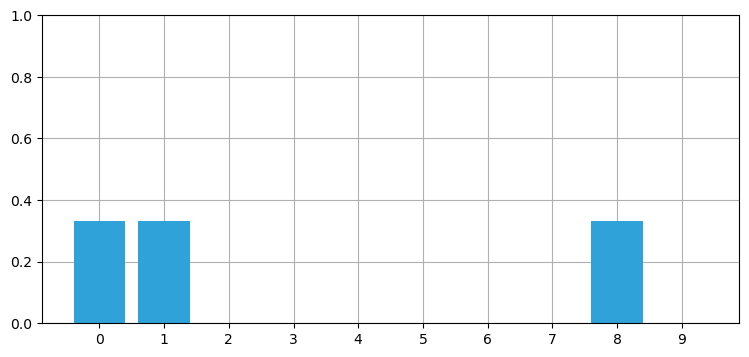

In [5]:
import kf_book.book_plots as book_plots
from kf_book.book_plots import figsize, set_figsize
import matplotlib.pyplot as plt

belief = np.array([1./3, 1./3, 0, 0, 0, 0, 0, 0, 1/3, 0])
book_plots.bar_plot(belief)

此分布称为[*分类分布（categorical distribution）*](https://en.wikipedia.org/wiki/Categorical_distribution)，它是描述了观察$n$的结果的概率的离散分布。也是[*多峰分布（multimodal distribution）*](https://en.wikipedia.org/wiki/Multimodal_distribution)，因为我们认为狗的位置有多种可能。 当然，我们并不是说我们认为它可以同时处于三个不同的位置，而只是说我们将考虑的情况缩小到这三个位置之一。 我（贝叶斯）的观点是，在门0处有33.3％的概率，在门1处有33.3％的概率，在门8处有33.3％的概率。

相比较这两种方式，这已经有所改进。我认为狗在走廊的某些位置是不可能的，我对剩下的位置的确信程度从10％增加到33％。 并随着我们的信息的增加，概率将接近100％。

我们再介绍一下分布的[*众数（mode）*](https://en.wikipedia.org/wiki/Mode_(statistics&#41;))。例如，给定一组数字{1,2,2,2,3,3,4}，*众数*是最常出现的数字。对于这个集合，众数为2。一个集合可以包含多个众数。 集合{1,2,2,2,3,3,4,4,4}的众数是2和4，因为两者都出现了三次。 我们说前者是[*单众数（unimodal）*](https://en.wikipedia.org/wiki/Unimodality)，后者是*多众数（multimodal）*。

关于分发的另一个术语是[*直方图（histogram）*](https://en.wikipedia.org/wiki/Histogram)。直方图以图形方式描绘一组数字的分布。 上面的条形图就是直方图。

我在上面的代码中手工编写了`belief`数组。我们如何在代码中实现这一点？我们用1表示门，墙用0表示，所以我们用走廊的变量乘以百分比，就像这样;

In [6]:
belief = hallway * (1./3)
print(belief)

[0.333 0.333 0.    0.    0.    0.    0.    0.    0.333 0.   ]


## 从传感器的读书中提取信息

让我们把Python放在一边，稍微考虑一下这个问题。假设我们从西蒙的传感器中读到以下内容：
  * 门 
  * 向右走
  * 门

我们可以推断出西蒙的位置吗？当然可以！鉴于走廊的布局，只有一个地方可以从中获得这个序列，那就是在最左端。因此，我们可以自信地说西蒙现在在第二个门口。如果你不清楚为什么，那么假设西蒙最早是在第二或第三门。向右移动后，它的传感器应该返回的是“墙壁”。这与传感器实际返回的结果不符，所以我们知道它不是从那里开始。对于其他剩余的起始位置，我们同样可以继续使用该逻辑。唯一可能的情况就是他现在在第二扇门前。我们的信念是：

In [7]:
belief = np.array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

我设计了走廊的布局和传感器的读数，所以可以快速给出答案。但是真正的问题不是那么明确。但这应该会给你一些启示 - 第一个传感器读数只给了我们西蒙位置的低概率（0.333），但在更新位置和得到另一个传感器读数之后我们更加了解它的位置了。 如果你有一个很长的走廊，有很多门，经过几次传感器读数和位置更新，我们要么能够知道西蒙在哪里，要么可以缩小西蒙可能的位置。一组传感器读数可能就仅仅只能匹配一个或几个起始位置。

我们现在可以实现这个解决方案了，但是让我们将真实世界的复杂性考虑进问题中。

## 传感器噪声

完美的传感器几乎是不可能的。如果西蒙正坐着在挠痒，或者如果它没有面对走廊，那么传感器就不会检测到门。因此，当我得到**门**时，我不能使用1/3作为概率。我应该为每扇门分配不到1/3的概率，并为每个空白墙位置分配一个小概率。 就像这样

```Python
[.31, .31, .01, .01, .01, .01, .01, .01, .31, .01]
```

初始值十分地关键。如果传感器有噪声，则我们会对每一次的数据都产生怀疑。如果我们总是不能确定，那我们怎么能得出结论呢？

对于上述问题，概率是答案。我们习惯于按概率来确定给狗的位置; 现在我们必须考虑传感器噪声所引起的额外的不确定性。

假设我们得到的结果是**门**，并且假设测试表明传感器测量门的正确率是错误率的3倍。我们应该在门的情况下将概率扩大3倍。 如果我们这样做，结果将不再是概率分布，我们将在后面介绍如何解决这个问题。

我们来看看Python代码中的内容。在这里，我使用变量`z`来表示测量。文献中习惯用`z`或`y`表示测量值。作为程序员，我更喜欢有意义的变量名，但我希望您能易于阅读文献或其他滤波器代码，所以我现在也使用这些缩写名称。

belief: [0.3 0.3 0.1 0.1 0.1 0.1 0.1 0.1 0.3 0.1]
sum = 1.6000000000000003


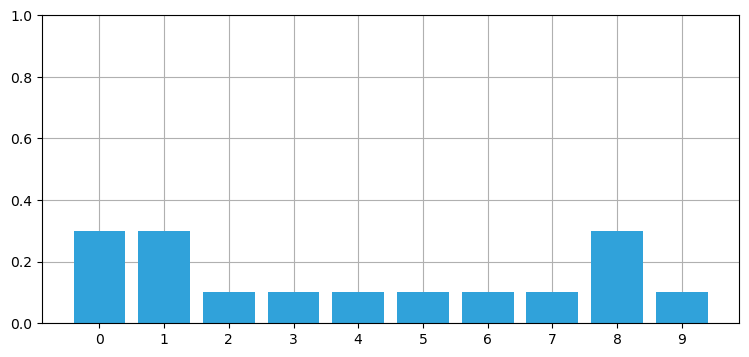

In [8]:
def update_belief(hall, belief, z, correct_scale):
    for i, val in enumerate(hall):
        if val == z:
            belief[i] *= correct_scale

belief = np.array([0.1] * 10)
reading = 1 # 1 is 'door'
update_belief(hallway, belief, z=reading, correct_scale=3.)
print('belief:', belief)
print('sum =', sum(belief))
plt.figure()
book_plots.bar_plot(belief)

这不是概率分布，因为它不总和为1.0。但是代码做了对的事——门被分配了一个概率（0.3），比墙壁（0.1）高3倍。我们需要做的就是将结果标准化，使概率正确地总和为1.0。通过将每个元素除以列表中所有元素的总和来完成标准化。使用NumPy很容易实现：

In [9]:
belief / sum(belief)

array([0.188, 0.188, 0.062, 0.062, 0.062, 0.062, 0.062, 0.062, 0.188,
       0.062])

FilterPy中用`normalize`函数实现它：

```Python
from filterpy.discrete_bayes import normalize
normalize(belief)
```

“正确率是错误率的3倍”的说法有点奇怪。我们正在处理概率，所以让我们指定传感器正确的概率，并从中计算比例因子。 对此的等式是

$$scale =  \frac{prob_{correct}}{prob_{incorrect}} = \frac{prob_{correct}} {1-prob_{correct}}$$


而且，`for`循环很麻烦。作为通常的规则，希望你避免在NumPy代码中使用`for`循环。NumPy是用C和Fortran实现的，因此如果避免for循环，结果通常比等效的循环快100倍。

我们如何避免使用`for`循环呢？NumPy允许您使用布尔数组索引数组。使用逻辑运算符创建布尔数组。我们可以找到走廊里的所有门：

In [10]:
hallway == 1

array([ True,  True, False, False, False, False, False, False,  True,
       False])

当您使用布尔数组作为另一个数组的索引时，它只返回索引为`True`的元素。因此我们可以用它替换`for`循环

```python
belief[hall==z] *= scale
```

只有`belief`中等于`z`的元素才会乘以`scale`。

教你使用NumPy超出了本书的范围。我会使用一些惯用的NumPy构造，我在第一次呈现它们时会解释它们。如果您是NumPy的新手，那么有很多关于如何有效和惯用地使用NumPy的博客文章和视频。

这是我们改进的版本：

sum = 1.0
probability of door = 0.1875
probability of wall = 0.06249999999999999


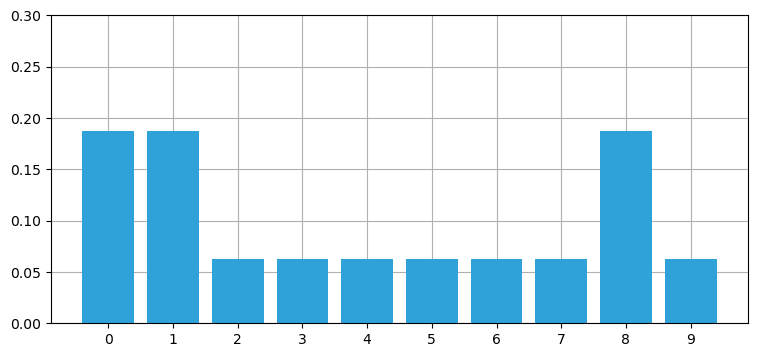

In [11]:
from filterpy.discrete_bayes import normalize

def scaled_update(hall, belief, z, z_prob): 
    scale = z_prob / (1. - z_prob)
    belief[hall==z] *= scale
    normalize(belief)

belief = np.array([0.1] * 10)
scaled_update(hallway, belief, z=1, z_prob=.75)

print('sum =', sum(belief))
print('probability of door =', belief[0])
print('probability of wall =', belief[2])
book_plots.bar_plot(belief, ylim=(0, .3))

我们可以从输出中看到现在的总和是1.0，并且门与墙的概率仍然是三倍。结果也符合我们的直觉，即门的概率必须小于0.333，并且墙的概率必须大于0.0。最后，我们尚未获得任何可以让我们区分任何特定的门或墙的位置的信息，因此所有门位置应该具有相同的值，对于所有的墙位置也是如此。

这个结果称为[*后验概率（posterior）*](https://en.wikipedia.org/wiki/Posterior_probability)，它是*后验概率分布*的缩写。是指在测量信息之后获得的概率分布*（在此上下文中后验概率的意思是'后面'）。前面讲的*先验概率*是测量信息之前的概率分布。

另一个术语是[*似然函数（likelihood）*](https://en.wikipedia.org/wiki/Likelihood_function)。当我们计算出`belief [hall == z] * = scale`时，我们计算了*每个位置被测量后的可能性*。似然函数不是概率分布，因为它的和不一定为1。

上面这些概念组合这个等式：

$$\mathtt{posterior} = \frac{\mathtt{likelihood} \times \mathtt{prior}}{\mathtt{normalization}}$$ 

当我们谈论滤波器的输出时，我们通常在执行预测后的状态叫做*先验概率*或*预测值*，并且我们在更新后将状态称为*后验概率*或*估计状态*。

学习和理解这些术语非常重要，因为大多数文献都广泛使用它们。

用`scaled_update（）`来执行这个计算吗？确实如此。让我把它改成这种形式：

In [12]:
def scaled_update(hall, belief, z, z_prob): 
    scale = z_prob / (1. - z_prob)
    likelihood = np.ones(len(hall))
    likelihood[hall==z] *= scale
    return normalize(likelihood * belief)

这个函数不是完全通用的。它包含有关走廊的信息，以及我们如何将测量结果与之匹配。我们应该尽量写通用的函数。在这里，我们要求调用者自己计算似然性，然后删除函数中似然值的计算。

下面是算法的完整实现：

```python
def update(likelihood, prior):
    return normalize(likelihood * prior)
```

每一个问题的似然值的计算各不相同。例如，传感器可能不只返回1或0，而是在0和1之间的一个浮点数，表示在门前的概率。在计算机视觉领域，会返回一个像素矩阵，然后通过概率匹配到一个门。也可能会使用声纳并返回一个距离读数。在每种情况下，似然值的计算都是不同的。我们将在整本书中看到许多这样的例子，并学习如何执行这些计算。

filterpy实现`update`函数，以下是上面例子的完全通用形式：

In [13]:
from filterpy.discrete_bayes import update

def lh_hallway(hall, z, z_prob):
    """ compute likelihood that a measurement matches
    positions in the hallway."""
    
    try:
        scale = z_prob / (1. - z_prob)
    except ZeroDivisionError:
        scale = 1e8

    likelihood = np.ones(len(hall))
    likelihood[hall==z] *= scale
    return likelihood

belief = np.array([0.1] * 10)
likelihood = lh_hallway(hallway, z=1, z_prob=.75)
update(likelihood, belief)  

array([0.188, 0.188, 0.062, 0.062, 0.062, 0.062, 0.062, 0.062, 0.188,
       0.062])

## 结合运动

回想一下，当我们进行一系列测量和位置更新时，我们是如何快速找到精确的解决方案的。然而，这这发生在一个有着完美传感器的虚拟世界里。我们能找到一个能够精确解决带有噪声的传感器的方案吗？

不幸的是，答案是否定的。即使传感器读数与极其复杂的走廊地图完全匹配，我们也不能百分之百地确定狗处于特定位置——毕竟，每个传感器读数都有可能出错！当然，在一个更典型的情况下，大多数传感器读数都是正确的，我们可能会接近100%确定我们的答案，但从来没有100%确定。这可能看起来很复杂，但让我们继续编程吧。

首先，让我们来处理这个简单的例子——假设运动传感器是完美的，并且它报告狗已经向右移动了一个空间。我们如何改变我们的`belief`数组？

经过思考，我们应该把`belief`数组所有的值右移一位。如果我们之前认为西蒙有50%的机会在3号位置，那么在他向右移动一个位置后，我们应该相信他有50%的机会在4号位置。走廊是圆形的，所以我们将使用模运算来实现移位。

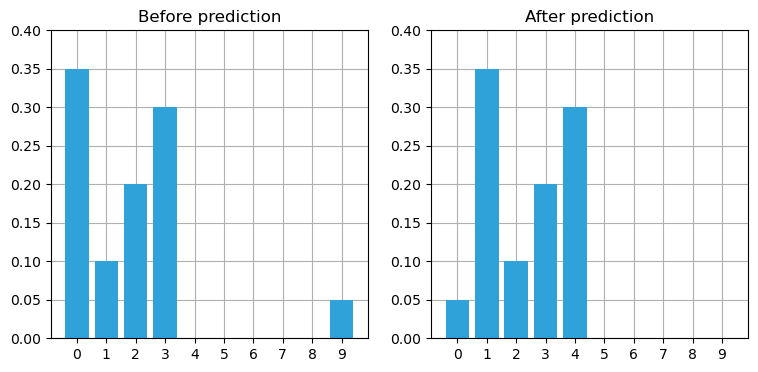

In [14]:
def perfect_predict(belief, move):
    """ move the position by `move` spaces, where positive is 
    to the right, and negative is to the left
    """
    n = len(belief)
    result = np.zeros(n)
    for i in range(n):
        result[i] = belief[(i-move) % n]
    return result
        
belief = np.array([.35, .1, .2, .3, 0, 0, 0, 0, 0, .05])
plt.subplot(121)
book_plots.bar_plot(belief, title='Before prediction', ylim=(0, .4))

belief = perfect_predict(belief, 1)
plt.subplot(122)
book_plots.bar_plot(belief, title='After prediction', ylim=(0, .4))

我们可以看到，我们将所有的值都正确的向右移了一个位置，数组的末尾移至了开头。

下面的单元格将对这个函数设置动画，以便您可以看到它的实际效果。使用滑块在时间轴上前后移动。这就像西蒙在走廊里走来走去。它还没有包含新的测量，所以概率分布不会改变形状，只改变位置。

interactive(children=(IntSlider(value=0, description='time_step', max=19), Output()), _dom_classes=('widget-in…

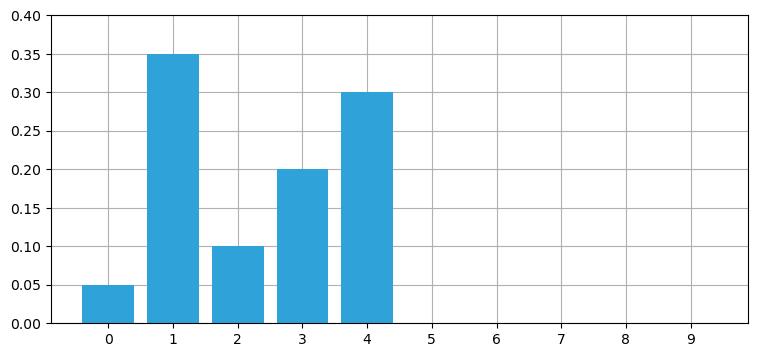

In [15]:
from ipywidgets import interact, IntSlider

belief = np.array([.35, .1, .2, .3, 0, 0, 0, 0, 0, .05])
beliefs = []

for _ in range(20):
    # Simon takes one step to the right
    belief = perfect_predict(belief, 1)
    beliefs.append(belief)

def simulate(time_step):
    book_plots.bar_plot(beliefs[time_step], ylim=(0, .4))
    
interact(simulate, time_step=IntSlider(value=0, max=len(beliefs)-1));

## 术语

让我们停下来回顾一下术语。我在上一章中介绍了一些术语，让我们花点时间来帮助巩固您的知识。

*系统（system）*是我们试图建模或滤波的对象。现在这个例子的系统是我们的狗。*状态（state）*是其当前配置或值。在这一章中，状态是指我们的狗的位置。我们无法知道实际的状态，所以我们用我们的滤波器产生对系统的*状态估计（estimated state）*。在实践中，这通常被称为状态，因此要仔细理解上下文。
 
通过测量指进行预测和更新的一个周期称为状态或系统的*演进*，它是*时间演进*[7]的缩写。另一个术语是*系统传播（system propagation）*。它指的是系统状态随时间的变化。对于滤波器，时间通常是一些按步长间隔的离散值，例如1秒。对于我们的狗追踪器，系统状态是狗的位置，状态演化是经过一段离散时间后的位置。 

我们使用*过程模型（process model）*对系统行为进行建模。在这个例子中，我们的过程模型是狗在每个时刻移动一个或多个位置。这并不是一个关于狗行为的精确模型。模型中的误差称为*系统误差（system error）*或*过程误差（process error）*。

我们用*先验概率（prior）*进行预测。时间向前推进，我们在不知道测量结果的情况下做出预测。

举个例子，狗的当前位置是在17米处。我们的每个时间步长是2秒，狗以15米/秒的速度行进。我们预测2秒后它后会在哪里？

很显然，

$$ \begin{aligned}
\bar x &= 17 + (15*2) \\
&= 47
\end{aligned}$$

我在变量上方加上横线来表示它们是先验（预测）。我们可以这样写过程模型的方程：

$$ \bar x_{k+1} = f_x(\bullet) + x_k$$

$x_k$是当前位置或状态。如果狗在17米处，那么$x_k = 17$。

$f_x（\bullet)$是x的状态传播函数。它描述了$x_k$在一个时间步长的变化量。对于我们的例子来说，它是$15\cdot 2$，因此我们将其定义为

$$f_x(v_x, t) = v_k t$$.

## 添加预测的不确定性

`perfect_predict()`假设测量结果完美，但所有的传感器都有噪声。如果传感器报告我们的狗移动了一个格，但实际上移动了两格，或者并没有动，怎么办？这听起来好像是一个无法解决的问题，但让我们先模拟一下，看看会发生什么。

假设传感器的运动测量值有80%的概率是正确的，10%概率会偏向右一个位置，10%的概率会向左偏一个位置。也就是说，如果运动测量值为4（即右方4个空格），则狗有80%可能向右移动4个格，10%可能向右移动3个格，10%可能向右移动5个格。

数组中的每个结果现在都需要包含3种不同情况下的概率。例如，传感器显示移动了2格。如果我们100%确定狗从位置3开始，那么它有80%的概率在5，10%的概率在4或6。让我们尝试编写代码：

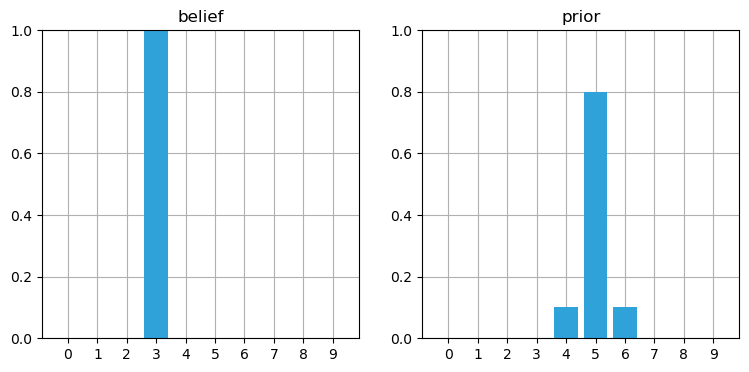

In [16]:
def predict_move(belief, move, p_under, p_correct, p_over):
    n = len(belief)
    prior = np.zeros(n)
    for i in range(n):
        prior[i] = (
            belief[(i-move) % n]   * p_correct +
            belief[(i-move-1) % n] * p_over +
            belief[(i-move+1) % n] * p_under)      
    return prior

belief = [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]
prior = predict_move(belief, 2, .1, .8, .1)
book_plots.plot_belief_vs_prior(belief, prior)

它似乎可以工作正常。如果当我们的belief不能百分之百确定时会发生什么？

array([0.  , 0.  , 0.  , 0.04, 0.38, 0.52, 0.06, 0.  , 0.  , 0.  ])

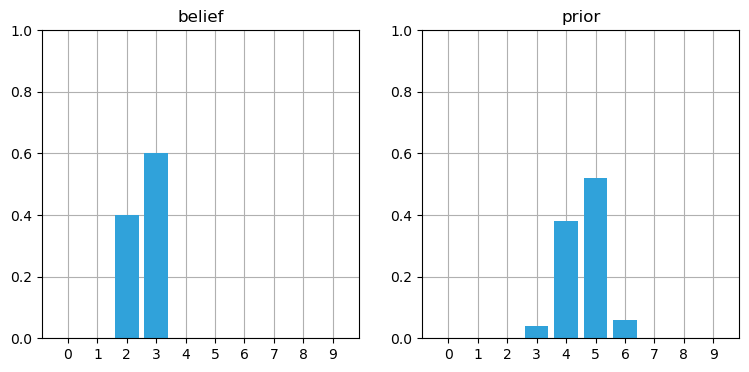

In [17]:
belief = [0, 0, .4, .6, 0, 0, 0, 0, 0, 0]
prior = predict_move(belief, 2, .1, .8, .1)
book_plots.plot_belief_vs_prior(belief, prior)
prior

这个结果更复杂，但是你仍然可以在头脑中计算出来。0.04是因为belief为04的话，有10%的概率移动了一个位置。0.38是由于以下原因：我们0.4的起始位置有80%的概率移动了2个位置（0.4 $\times$ 0.8），0.6的起始位置有10%的概率我们移一个位置（0.6 $\times$ 0.1）。偏右的预测在这里不起作用，因为如果我们偏右预测0.4和0.6的起始位置，就会超过这个位置。**我强烈建议理解这个示例，直到清楚每个概率是如何得到的，因为下面的大部分内容取决于理解此步骤。**

如果在执行更新后查看概率，可能会感到失望。在上面的例子中，我们从概率0.4和0.6的两个位置开始；执行更新后，概率不仅降低，而且在地图上更加分散。

这不是巧合，也不是精心挑选预测总是正确的的例子。如果传感器有噪声，我们每次预测会丢失一些信息。假设我们要无限次地执行预测——结果会是什么？我们在每一步上都丢失了信息，我们最终就必须完全没有信息，我们的概率将平均分布在`belief`数组中。让我们尝试100次迭代预测更新。绘图已设置动画；使用滑块更改步骤号。

Final Belief: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


interactive(children=(IntSlider(value=1, description='step'), Output()), _dom_classes=('widget-interact',))

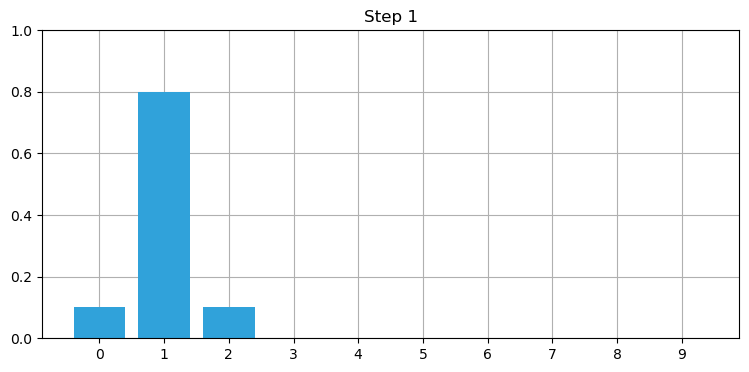

In [40]:
belief = np.array([1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
beliefs = []
    
for i in range(100):
    belief = predict_move(belief, 1, .1, .8, .1)
    beliefs.append(belief)

print('Final Belief:', belief)

# make interactive plot
def show_prior(step):
    book_plots.bar_plot(beliefs[step-1])
    plt.title('Step {}'.format(step))

interact(show_prior, step=IntSlider(value=1, max=len(beliefs)));

In [19]:
print('Final Belief:', belief)

Final Belief: [0.104 0.103 0.101 0.099 0.097 0.096 0.097 0.099 0.101 0.103]


在100次迭代之后，我们几乎失去了所有的信息，即使我们100%确信我们从位置0开始。您可以随意调整迭代次数来查看不同更新次数的效果。例如，在100次更新之后，会留下少量信息，在50次之后会留下大量信息，但到了200次迭代，基本上所有信息都会丢失。

如果你在网上看这个，这里有一个输出的动画。
<img src="animations/02_no_info.gif">

我不会在书的其余部分生成这些独立的动画。有关在网上免费运行本书或在计算机上安装ipython的说明，请参阅前言。这将允许您运行所有单元格并查看动画。这是非常重要的，你实践这段代码，而不仅仅是被动地阅读。

## 卷积泛化

我们之前假设运动误差偏差一个位置。但误差可能是两个、三个或更多的位置。作为程序员，我们总是希望抽象我们的代码，以便它适用于所有情况。

这很容易通过[*卷积*](https://en.wikipedia.org/wiki/covolcution)解决。卷积用另一个函数修改一个函数。在我们的例子中，我们用传感器的误差函数来修改概率分布。`predict_move()`就是一个基于卷积的实现方法，尽管我们没有这样称呼它。卷积的形式定义为：

$$ (f \ast g) (t) = \int_0^t \!f(\tau) \, g(t-\tau) \, \mathrm{d}\tau$$

$f\ast g$ 是f对g的卷积的表示，它并不是表示乘积。

积分适用于连续函数，但我们用的是离散函数。我们需要用求和替换积分，用数组括号替换圆括号。

$$ (f \ast g) [t] = \sum\limits_{\tau=0}^t \!f[\tau] \, g[t-\tau]$$

`predict_move()`按这个方程-它计算一系列乘法的和。

[Khan Academy](https://www.khanacolademy.org/math/differential-equations/laplace-transform/covolcution-integral/v/introduction-to-the-covolcution)[4]对卷积有很好的介绍，维基百科对卷积有很好的动画效果演示[5]。但总体思路已经很清楚了。您可以将一个名为*内核*的数组滑动到另一个数组中，将当前单元格的邻居与第二个数组的值相乘。在上面的示例中，我们使用0.8表示移动到正确位置的概率，0.1表示欠冲，另0.1表示过冲。我们用数组`[0.1，0.8，0.1]`作为它的核心。我们需要做的就是编写一个循环，遍历数组的每个元素，乘以内核，并求和结果。为了强调这个belief是一个概率分布，我把它命名为“pdf”。

In [20]:
def predict_move_convolution(pdf, offset, kernel):
    N = len(pdf)
    kN = len(kernel)
    width = int((kN - 1) / 2)

    prior = np.zeros(N)
    for i in range(N):
        for k in range (kN):
            index = (i + (width-k) - offset) % N
            prior[i] += pdf[index] * kernel[k]
    return prior

这只是说明了算法的原理，但它的运行速度非常慢。SciPy在`ndImage.filters`模块中提供了一个卷积的方法`convole（）`。在卷积之前，我们需要将pdf按`offset`进行位移；而`np.roll（）`可以实现。移动和预测算法可以用一行来实现：

```python
convolve(np.roll(pdf, offset), kernel, mode='wrap')
```
FilterPy使用`discrete_bayes`中的`predict（）`函数实现了这个功能

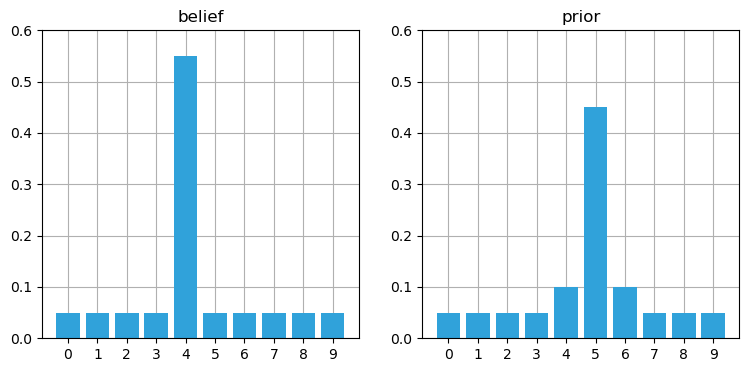

In [21]:
from filterpy.discrete_bayes import predict

belief = [.05, .05, .05, .05, .55, .05, .05, .05, .05, .05]
prior = predict(belief, offset=1, kernel=[.1, .8, .1])
book_plots.plot_belief_vs_prior(belief, prior, ylim=(0,0.6))

除中间三个个元素外，其他元素的值都没有变化。其中位置4和6中的值应为
$$(0.1 \times 0.05)+ (0.8 \times 0.05) + (0.1 \times 0.55) = 0.1$$

位置5的值为： $$(0.1 \times 0.05) + (0.8 \times 0.55)+ (0.1 \times 0.05) = 0.45$$

让我们通过移动位置大于和使用一个非对称的内核来验证这个函数可以正确地移动位置。

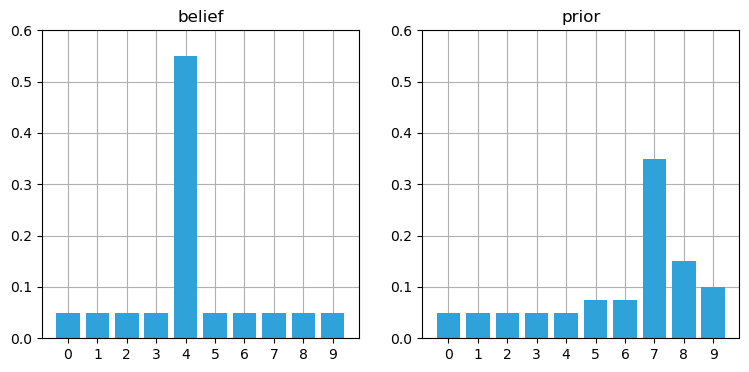

In [22]:
prior = predict(belief, offset=3, kernel=[.05, .05, .6, .2, .1])
book_plots.plot_belief_vs_prior(belief, prior, ylim=(0,0.6))

通过上图可以看到正确地移动了3个位置，我们把过冲比欠冲的概率给予了更大的权重，所以这看起来是正确的。

请确保你能明白我们正在做什么。我们正在预测狗在向哪里移动，并通过卷积概率以获得先验概率。

我们之前不使用概率时所给出的方程是这样的：

$$ \bar x_{k+1} = x_k + f_{\mathbf x}(\bullet)$$

之前，我们对狗的位置的预测，是狗移动的距离加上它当前的位置。如果那条狗在10米处，它移动了5米，那么它现在在15米。这是再简单不过了。但是现在我们用概率来建模，所以我们的方程是：

$$ \bar{ \mathbf x}_{k+1} = \mathbf x_k \ast f_{\mathbf x}(\bullet)$$

我们将当前的概率位置估计与我们认为狗移动了多少的概率估计进行*卷积*。虽然两个x看上去差不多，但在数学上的含义是不一样的。粗体的$\mathbf x$表示它是一个数组。

## 整合测量和运动更新

由于在预测过程中会丢失信息，看起来好像我们的系统是很快就不知所措了。然而，我们每次预测之后都会有一个更新，我们会将新的测量结果纳入估计。更新提高了我们知悉的内容。更新步骤的输出会被送入下一次预测。预测会降低了我们的确定性。但是当预测的结果被传递到下次的更新中时，确定性将会再次增加。

让我们直观地思考一下。考虑一个简单的例子——你在跟踪一只狗，而它却坐着不动。在每次预测中，你都预测它不会动。你的滤波器针对它的位置很快就会*收敛*到精确的估计上。然后厨房里的微波炉打开了，它就开始向厨房奔跑。你并不知道这一点，所以在下一次预测中，你还是预测它在同一地点。但和测量结果却不同。当你把这些测量数据结合起来时，你的认知的概率就会分布在通向厨房的走廊数组中。在每一迭代（周期），你认为他静止不动的信念会变小，你认为他以惊人的速度奔向厨房的信念在增加。

这是直觉告诉我们的。那么数学会告诉我们什么？

我们已经对更新和预测步骤编写了代码。我们需要做的就是将一个结果输入另一个结果，最终实现一个狗的跟踪程序！！！！让我们看看它是如何工作的。我们将输入测量值，就好像狗从0开始，每一个时期向右移动一个位置。考虑在现实世界中，我们并不知道它的起始位置，所以为所有位置分配相等的概率。

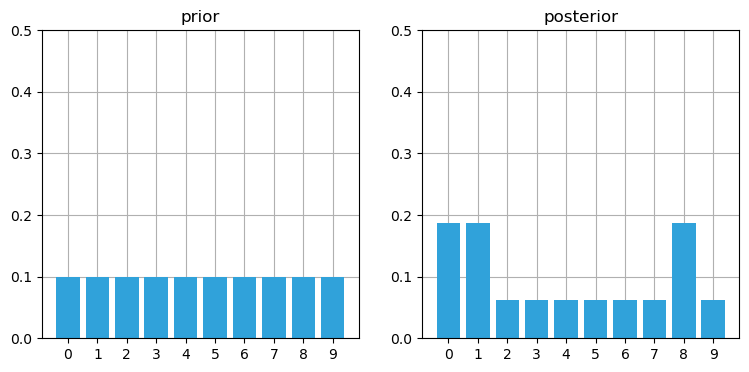

In [23]:
from filterpy.discrete_bayes import update

hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])
prior = np.array([.1] * 10)
likelihood = lh_hallway(hallway, z=1, z_prob=.75)
posterior = update(likelihood, prior)
book_plots.plot_prior_vs_posterior(prior, posterior, ylim=(0,.5))

在第一次更新之后，我们为每个门的位置分配了更高的概率，为每个墙位置分配了更低的概率。

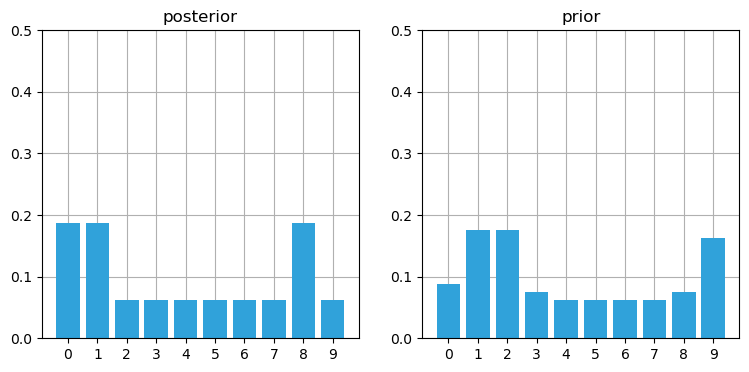

In [24]:
kernel = (.1, .8, .1)
prior = predict(posterior, 1, kernel)
book_plots.plot_prior_vs_posterior(prior, posterior, True, ylim=(0,.5))

预测步骤将这些概率向右移一位，这会使它们变得有点平均。现在让我们看看下一步会发生了什么。

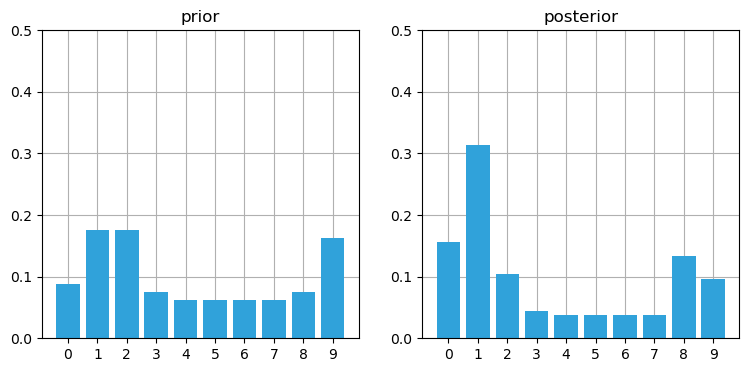

In [25]:
likelihood = lh_hallway(hallway, z=1, z_prob=.75)
posterior = update(likelihood, prior)
book_plots.plot_prior_vs_posterior(prior, posterior, ylim=(0,.5))

注意位置1的柱形图。这与从位置0开始感应门、向右移动1后感应另一扇门的（正确）情况相对应。没有其他位置会出现这样的观察结果。现在我们将再添加一次更新，然后传感器的结果表示是墙。

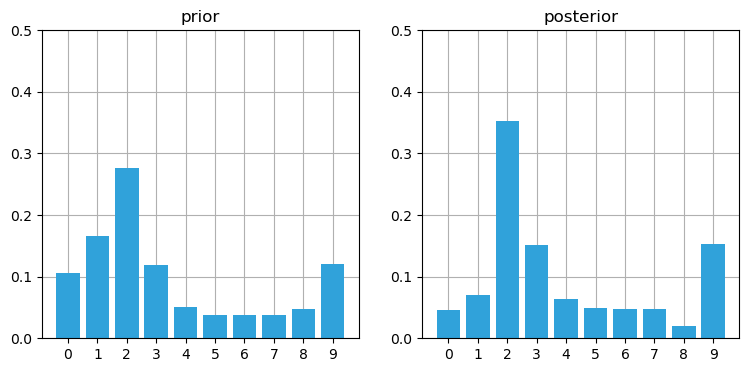

In [26]:
prior = predict(posterior, 1, kernel)
likelihood = lh_hallway(hallway, z=0, z_prob=.75)
posterior = update(likelihood, prior)
book_plots.plot_prior_vs_posterior(prior, posterior, ylim=(0,.5))

这太令人兴奋了！我们在2号位置得到了一个非常突出的柱形图，它的值约为35%。它是绘图中任何其他条形图的两倍以上，比上一次绘图中最高的31%，增加了4%。让我们再进行一次循环。

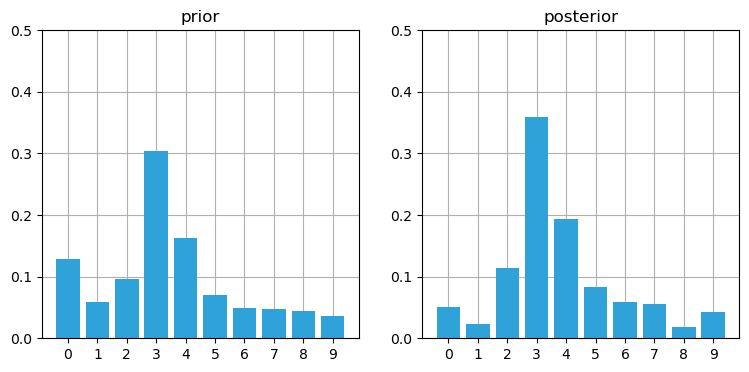

In [27]:
prior = predict(posterior, 1, kernel)
likelihood = lh_hallway(hallway, z=0, z_prob=.75)
posterior = update(likelihood, prior)
book_plots.plot_prior_vs_posterior(prior, posterior, ylim=(0,.5))

我忽略了一个重要问题。之前我假设我们有一个用于预测的运动传感器；然后，当谈到狗和微波炉时，我假设你不知道狗何时突然开始奔跑。我提到你认为狗在跑的信念会随着时间的推移而增加，但我没有为此提供任何代码。简而言之，如果我们不直接测量过程模型中的变化，我们要如何检测或评估它呢？

现在我想忽略这个问题。在后面的章节中，我们将学习这个估计背后的数学知识；现在，仅仅学习这个算法就足够了。解决这个问题是非常重要的，但是我们还没有建立足够的数学体系，所以在本章的其余部分，我们将忽略这个问题，只假设我们有一个可以感知运动传感器。

## 离散贝叶斯算法

下面是这个算法的流程图：

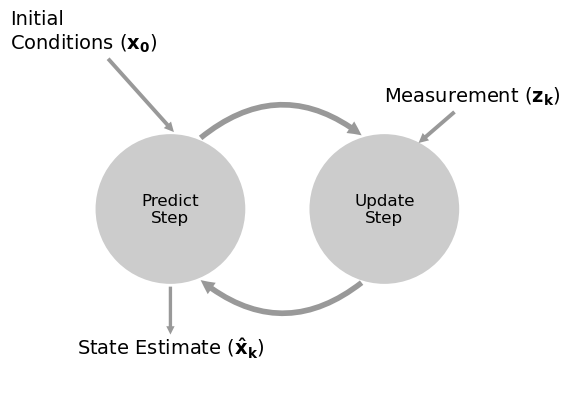

In [28]:
book_plots.predict_update_chart()

这个滤波器是g-h滤波器的一种形式。这里，我们用误差百分比隐式计算$g$和$h$参数。我们可以用离散贝叶斯算法表示为g-h滤波器，但这会掩盖该滤波器的逻辑。

滤波器的方程为：

$$\begin{aligned} \bar {\mathbf x} &= \mathbf x \ast f_{\mathbf x}(\bullet)\, \, &\text{Predict Step} \\
\mathbf x &= \|\mathcal L \cdot \bar{\mathbf x}\|\, \, &\text{Update Step}\end{aligned}$$

$\mathcal L$是表示似然函数时的常用方法，因此我用到了它。$\|\|$符号表示取范数。我们需要规范化表示似然值与先验概率的乘积，以确保$x$是一个和为1的概率分布。

我们可以用伪代码表示。

**初始化**

    1.初始化系统状态的数组belief
    
**预测**

    1.基于系统行为，预测下一时刻状态
    2.根据预测概率调整belief数组
    
**更新**

    1.获取测量值，并结合测量准确性
    2.计算测量值符合各个状态的似然值
    3.根据似然值更新belief数组

当我们后面讨论卡尔曼滤波器时，我们将使用完全相同的算法；只有计算的细节会略有不同。

这种形式的算法有时被称为*预测校正器（predictor correctors）*。我们做出一个预测，然后纠正它。

让我们制作这个滤波器的动画。首先，让我们编写函数来执行滤波并绘制出每一步的结果。我用黑色表示门口的位置。先验概率用橙色，后验概率用蓝色画。我画了一条粗竖线来表示西蒙的真实位置。我们知道西蒙在哪里，只是因为我们在模拟它的动作，它这不是滤波器的输出。

In [29]:
def discrete_bayes_sim(prior, kernel, measurements, z_prob, hallway):
    posterior = np.array([.1]*10)
    priors, posteriors = [], []
    for i, z in enumerate(measurements):
        prior = predict(posterior, 1, kernel)
        priors.append(prior)

        likelihood = lh_hallway(hallway, z, z_prob)
        posterior = update(likelihood, prior)
        posteriors.append(posterior)
    return priors, posteriors


def plot_posterior(posteriors, i):
    plt.title('Posterior')
    book_plots.bar_plot(hallway, c='k')
    book_plots.bar_plot(posteriors[i], ylim=(0, 1.0))
    plt.axvline(i % len(hallway), lw=5)    
    
def plot_prior(priors, i):
    plt.title('Prior')
    book_plots.bar_plot(hallway, c='k')
    book_plots.bar_plot(priors[i], ylim=(0, 1.0), c='#ff8015')
    plt.axvline(i % len(hallway), lw=5)    

def animate_discrete_bayes(step):
    step -= 1
    i = step // 2    
    if step % 2 == 0:
        plot_prior(priors, i)
    else:
        plot_posterior(posteriors, i)

让我们运行这个滤波器并查看动画。

interactive(children=(IntSlider(value=1, description='step'), Output()), _dom_classes=('widget-interact',))

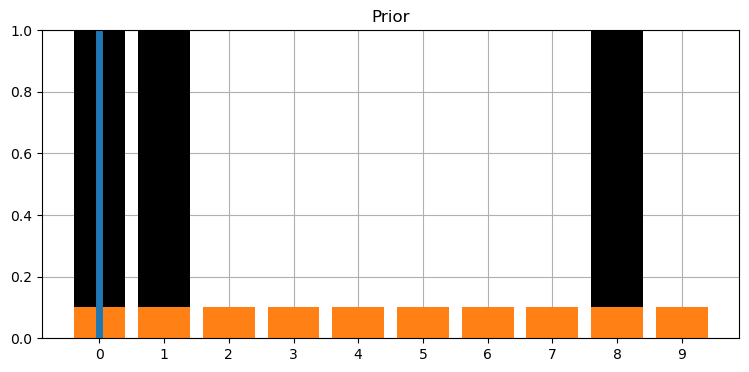

In [30]:
# change these numbers to alter the simulation
kernel = (.1, .8, .1)
z_prob = 1.0
hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])

# measurements with no noise
zs = [hallway[i % len(hallway)] for i in range(50)]

priors, posteriors = discrete_bayes_sim(prior, kernel, zs, z_prob, hallway)
interact(animate_discrete_bayes, step=IntSlider(value=1, max=len(zs)*2));

现在我们可以看到结果。你可以看到如何的先验概率是如何移动的，确定性是如何降低的，而相同位置的后验概率，因为通过测量增加了信息，所以它又会是确定性增加。前面我认为测量值是准确无误的，`z_prob = 1.0`，最后，我们会在下一节探索有瑕疵的测量对结果的影响。

另一个需要注意的是，当我们站在门前时，我们的估计值会变得有多准，而当我们站在走廊中间时，我们的估计又会变有多不准。这应该是直观的。只里只有几个门，所以当传感器告诉我们在门前时，这就提高了我们对位置的确定性。反之，如果很长时间都告诉我们没有检测到门，显然会降低我们的确定性。

## 不好的传感器数据的影响

您可能怀疑上述结论，因为我总是将正确的传感器数据传递给函数。但是，我们声称这个代码实现了一个*滤波器*，那么它应该可以过滤掉错误的传感器测量值。它可以做到吗？

为了便于编程和可视化，我将把走廊的布局改为大部分交替的门和走廊，并在6个正确的测量值上运行算法：

interactive(children=(IntSlider(value=12, description='step', max=12), Output()), _dom_classes=('widget-intera…

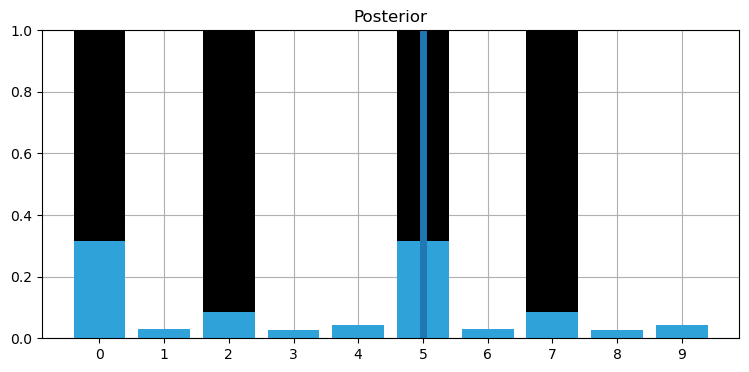

In [31]:
hallway = np.array([1, 0, 1, 0, 0]*2)
kernel = (.1, .8, .1)
prior = np.array([.1] * 10)
zs = [1, 0, 1, 0, 0, 1]
z_prob = 0.75
priors, posteriors = discrete_bayes_sim(prior, kernel, zs, z_prob, hallway)
interact(animate_discrete_bayes, step=IntSlider(value=12, max=len(zs)*2));

我们已经确定了从0或5位置开始的可能情况，因为我们看到了门和墙的序列：1,0,1,0,0。现在我输入了一个错误的度量。下一个测量应该是0，如果我们得到的测量值是1：

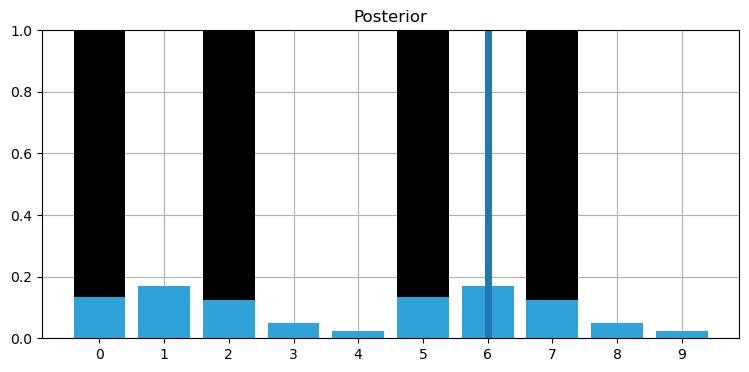

In [32]:
measurements = [1, 0, 1, 0, 0, 1, 1]
priors, posteriors = discrete_bayes_sim(prior, kernel, measurements, z_prob, hallway);
plot_posterior(posteriors, 6)

一个糟糕的测量值已经严重破坏了我们的认知。现在让我们继续进行一系列正确的测量。

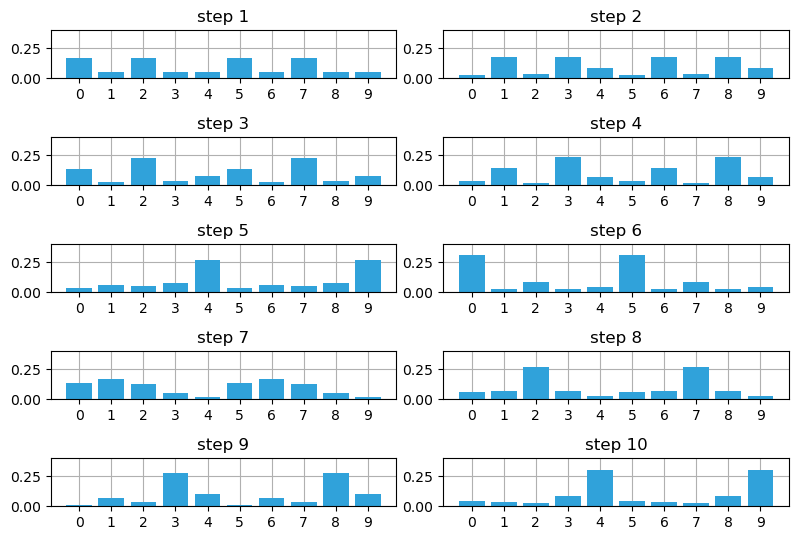

In [33]:
with figsize(y=5.5):
    measurements = [1, 0, 1, 0, 0, 1, 1, 1, 0, 0]
    for i, m in enumerate(measurements):
        likelihood = lh_hallway(hallway, z=m, z_prob=.75)
        posterior = update(likelihood, prior)
        prior = predict(posterior, 1, kernel)
        plt.subplot(5, 2, i+1)
        book_plots.bar_plot(posterior, ylim=(0, .4), title='step {}'.format(i+1))
    plt.tight_layout()

从上图可以看出来，我们很快地过滤掉了错误的传感器读数，并给出了一个我们的狗最可能的位置。

## 缺点和限制

不要被我选择的这个简单的例子所误导。这是一个健壮和完整的过滤器，您可以在实际解决方案中使用该代码。如果你需要一个多模态的离散滤波器，这个滤波器可以应对。

尽管如此，这个滤波器很少被用到，因为它有一些限制。克服这些限制会在本书其余章节讲到。

第一个问题是缩放。狗跟踪问题只使用了一个变量$pos$，用来表示狗的位置。实际的问题往往是要在一个大空间中跟踪好几个东西。实际上，想追踪我们的狗至少需要坐标$（x，y）$，可能还有它的速度坐标$（\dot x，\dot y）$。我们虽然没有讨论多维的情况，但是我们可以使用多维数组来存储每个离散位置的概率。每个`update()`和`predict()`步骤都需要更新多维数组中的所有值，因此一个简单的四变量问题*每个时间步骤*需要$O（n^4）$运行时间。现实中的滤波器可能有10个或更多的变量需要跟踪，从而导致很高的计算需求。

第二个问题是这个滤波器是离散的，但是我们生活在一个连续的世界里。柱状图要求将滤波器的输出为一组离散点。如果精确到1厘米，100米的走廊需要10000个位置来模拟。因此，每次更新和预测操作都需要对10000个不同的概率进行计算。当我们添加维度时，它会以指数形式增加。一个100x100米的$^2$院子需要100000000个点才能达到1厘米的精度。

第三个问题是滤波器是多模态的。在上一个例子中，我们最终坚定地相信狗处于第4个或第9个位置。这并不总是个问题。我们稍后将研究的粒子滤波器是多模的，这种特性是经常用到的。但是想象一下，如果你车里的GPS报告你，40%的概率确定你在D街，30%的概率确定你在威洛大街。

第四个问题是它需要测量状态的变化。我们需要一个运动传感器来检测狗的运动。有很多方法可以解决这个问题，但这会使本章的论述复杂化，因此，考虑到前面提到的问题，我将不再进一步讨论它。

总之，如果我有一个这个方法可以处理的小问题，我会选择使用它；因为它实现简单、便于调试和理解。

## 跟踪和控制

前面我们一直在被动地跟踪一个自主运动的物体。但考虑一个非常相似的问题。假设我正在建设一个自动化仓库，想用机器人为客户的订单收集所有物品。也许最简单的方法就是让机器人在轨道上行走。我想能把机器人送去一个目的地，然后让它自己去那里。但轨道和机器人的马达都不足够好。车轮会打滑和不完美的马达意味着机器人不可能精确地移动到你所指定的位置。为了使他们不会撞到一起，我们需要知道每一个机器人各自在什么地方。

所以我们增加了传感器。我们每隔几英尺就在轨道上安装磁铁，并使用霍尔传感器来计算通过的磁铁数量。如果传感器计算得出了10，那么机器人应该在第10个磁铁。当然，有可能会漏数一块磁铁，或者把它数到两次，所以我们必须适应一定程度的误差。我们可以使用上一节中的代码来跟踪我们的机器人，因为磁铁计数与门口感应非常相似。

我们还没有做完。我们已经学会了永不丢弃信息。如果你有了信息，你应该用它来提高你的估计。我们遗漏了什么信息？我们知道在每一时刻，我们都在向机器人的轮子提供了什么样的控制输入。例如，假设我们每秒向机器人发送一次移动命令-向左移动1个单位，或者向右移动1个单位，或者静止不动。如果我发送了“左移1个单位”的命令，我希望从现在开始的一秒钟内，机器人将从它现在所在的位置向左侧移动1个单位。这是一中简化情况，因为我不考虑加速度，我不想教控制理论。车轮和马达不完善。机器人可能会停在0.9单位，或者1.2单位的位置。

现在整个解决方案都清楚了。我们假设那条狗一直朝着它前面的方向移动。这对我的狗来说是个不现实的假设！但机器人更容易预测。我们不会根据假设的行为做出错误的预测，而是输入我们发送给机器人的命令！换句话说，当我们调用`predict()`时，我们将传入给机器人动作的命令以及描述该动作可能性的核。


### 模拟列车行为

我们需要模拟一个不完美的火车。当我们命令它移动时，它有时会犯一个小错误，它的传感器有时会返回错误的值。

In [34]:
class Train(object):

    def __init__(self, track_len, kernel=[1.], sensor_accuracy=.9):
        self.track_len = track_len
        self.pos = 0
        self.kernel = kernel
        self.sensor_accuracy = sensor_accuracy

    def move(self, distance=1):
        """ move in the specified direction
        with some small chance of error"""

        self.pos += distance
        # insert random movement error according to kernel
        r = random.random()
        s = 0
        offset = -(len(self.kernel) - 1) / 2
        for k in self.kernel:
            s += k
            if r <= s:
                break
            offset += 1
        self.pos = int((self.pos + offset) % self.track_len)
        return self.pos

    def sense(self):
        pos = self.pos
         # insert random sensor error
        if random.random() > self.sensor_accuracy:
            if random.random() > 0.5:
                pos += 1
            else:
                pos -= 1
        return pos

这样我们就可以开始编写滤波器了。我们把它放到一个函数中，这样我们就可以用不同的假设条件来运行它。我假设机器人总是从轨道起始的位置开始。轨道的长度为10个单位，但可以将其视为长度为10000的轨道，磁铁模组每10个单位重复一次。长度为10是为了便于绘制和观察。

In [35]:
def train_filter(iterations, kernel, sensor_accuracy, 
             move_distance, do_print=True):
    track = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    prior = np.array([.9] + [0.01]*9)
    posterior = prior[:]
    normalize(prior)
    
    robot = Train(len(track), kernel, sensor_accuracy)
    for i in range(iterations):
        # move the robot and
        robot.move(distance=move_distance)

        # peform prediction
        prior = predict(posterior, move_distance, kernel)       

        #  and update the filter
        m = robot.sense()
        likelihood = lh_hallway(track, m, sensor_accuracy)
        posterior = update(likelihood, prior)
        index = np.argmax(posterior)

        if do_print:
            print('''time {}: pos {}, sensed {}, '''
                  '''at position {}'''.format(
                    i, robot.pos, m, track[robot.pos]))

            print('''        estimated position is {}'''
                  ''' with confidence {:.4f}%:'''.format(
                  index, posterior[index]*100))            

    book_plots.bar_plot(posterior)
    if do_print:
        print()
        print('final position is', robot.pos)
        index = np.argmax(posterior)
        print('''Estimated position is {} with '''
              '''confidence {:.4f}%:'''.format(
                index, posterior[index]*100))

阅读这段代码并确保您能理解它。现在让我们在没有传感器误差或移动误差的情况下运行一次。如果代码是正确的，它应该能够在没有误差的情况下准确定位机器人的位置。输出读起来有点乏味，但是如果你完全不确定更新/预测周期是如何工作的，请确保仔细阅读它以巩固你的理解。

time 0: pos 4, sensed 4, at position 4
        estimated position is 4 with confidence 99.9900%:
time 1: pos 8, sensed 8, at position 8
        estimated position is 8 with confidence 100.0000%:
time 2: pos 2, sensed 2, at position 2
        estimated position is 2 with confidence 100.0000%:
time 3: pos 6, sensed 6, at position 6
        estimated position is 6 with confidence 100.0000%:

final position is 6
Estimated position is 6 with confidence 100.0000%:


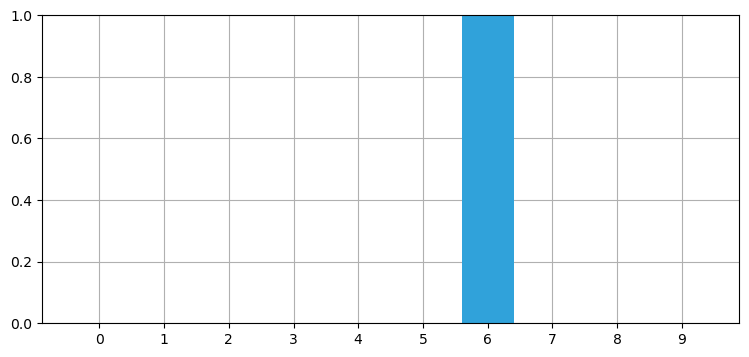

In [36]:
import random

random.seed(3)
np.set_printoptions(precision=2, suppress=True, linewidth=60)
train_filter(4, kernel=[1.], sensor_accuracy=.999,
             move_distance=4, do_print=True)

我们可以看到，这个代码能够完美地跟踪机器人，所以我们应该有足够的信心，代码是工作的。现在让我们看看它是如何处理有误差的情况的。

time 0: pos 4, sensed 4, at position 4
        estimated position is 4 with confidence 96.0390%:
time 1: pos 8, sensed 9, at position 8
        estimated position is 9 with confidence 52.1180%:
time 2: pos 3, sensed 3, at position 3
        estimated position is 3 with confidence 88.3993%:
time 3: pos 7, sensed 8, at position 7
        estimated position is 8 with confidence 49.3174%:

final position is 7
Estimated position is 8 with confidence 49.3174%:


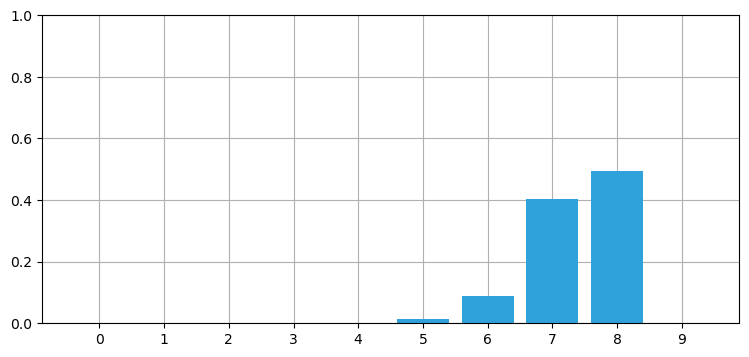

In [37]:
random.seed(5)
train_filter(4, kernel=[.1, .8, .1], sensor_accuracy=.9,
         move_distance=4, do_print=True)

在第个1时刻，有一些误差，但我们仍然对我们估计的位置很有信心。

现在让我们运行一个长时间的模拟，看看过滤器如何处理误差的。

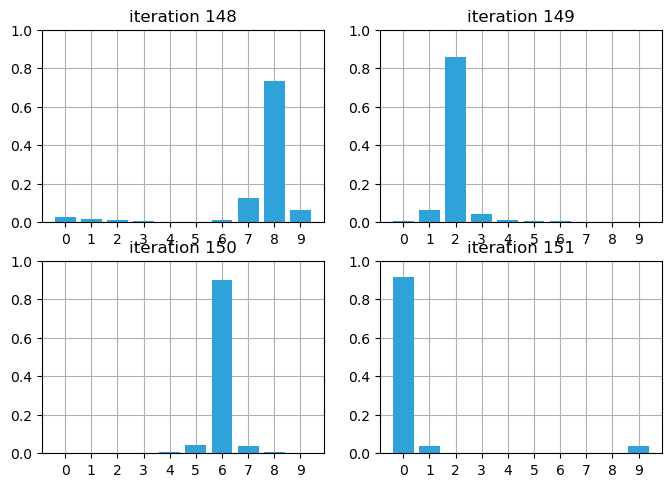

In [38]:
with figsize(y=5.5):
    for i in range (4):
        random.seed(3)
        plt.subplot(221+i)
        train_filter(148+i, kernel=[.1, .8, .1], 
                     sensor_accuracy=.8,
                     move_distance=4, do_print=False)
        plt.title ('iteration {}'.format(148+i))

我们可以看到，随着置信度的降低，在149次迭代出现了问题。但在几次迭代中，滤波器能够自我校正并重新获得正确的位置估计。

## 贝叶斯定理和全概率定理

我们在这一章中仅仅根据我们对每一时刻所掌握的信息进行推理来学习了数学。在这个过程中，我们认识了[*贝叶斯定理*](https://en.wikipedia.org/wiki/bayes%27_theorem)和[*全概率定理*](https://en.wikipedia.org/wiki/law_of_total_probability)。

贝叶斯定理告诉我们如何在已知信息的情况下计算事件的概率。

我们通过`update()`函数实现了概率计算：

$$ \mathtt{posterior} = \frac{\mathtt{likelihood}\times \mathtt{prior}}{\mathtt{normalization\, factor}}$$ 

我们没有深入讨论贝叶斯的数学理论，但这就是贝叶斯定理。这本书中的每一个滤波器都是基于贝叶斯定理的一个表达。在下一章中，我们将继续数学理论，但在许多方面，它会隐藏方程式中所表达的简单概念：

$$ updated\,knowledge = \big\|likelihood\,of\,new\,knowledge\times prior\, knowledge \big\|$$

其中$\| \cdot\|$ 表示范化术语。

我们只是简单地推理了一条狗在走廊里走来走去。然而，正如我们将看到的，同样的方程也适用于宇宙中滤波问题。我们将在后面的每一章中使用到这个方程。

同样地，`predict()`的步骤计算多个可能事件的总概率。这在统计学中被称为*全概率定理*，在了解一些相关数学理论之后，我们也将在下一章中讨论这一点。

现在，我需要你们知道，贝叶斯定理是一个将新信息合并到现有信息中的公式。

## 总结

代码很简短，但结果令人印象深刻！我们实现了贝叶斯滤波器的一种形式。我们已经学会了如何从没有信息的情况开始，从有噪声的传感器中获取信息。尽管本章中的传感器噪声很大（例如，大多数传感器的准确度都超过80%），但我们依然很快就定位在我们的狗最可能的位置。我们已经了解了预测步骤是如何降低我们的判断，但是添加另一个测量值之后，即使其中可能有噪声，也会提高我们的判断，使我们的可能性能够集中在最可能的结果上。

这本书主要是关于卡尔曼滤波器的。它使用的数学理论和贝叶斯滤波器是不同的，但逻辑与本章中使用的完全相同。它使用贝叶斯定理从测量和过程模型的组合中形成估计。

**如果你能理解这一章，你将能够理解和实现卡尔曼滤波器。**我要再次强调这一点。如果有什么东西是没有明白的，回去重读这一章，跑代码。这本书的其余部分将建立在我们在这里使用的算法之上。如果你不明白这个过滤器是怎样工作的，那么剩下的章节就没什么效果了。然而，如果你掌握了基本的洞察力——我们测量时的概率倍增，我们更新时的概率转移会导致一个聚合的解决方案——那么在学习了一点数学理论之后，你就可以准备好实现一个卡尔曼滤波器了。

## 参考文献

 * [1] D. Fox, W. Burgard, and S. Thrun. "Monte carlo localization: Efficient position estimation for mobile robots." In *Journal of Artifical Intelligence Research*, 1999.
 
 http://www.cs.cmu.edu/afs/cs/project/jair/pub/volume11/fox99a-html/jair-localize.html


 * [2] Dieter Fox, et. al. "Bayesian Filters for Location Estimation". In *IEEE Pervasive Computing*, September 2003.
 
 http://swarmlab.unimaas.nl/wp-content/uploads/2012/07/fox2003bayesian.pdf
 
 
 * [3] Sebastian Thrun. "Artificial Intelligence for Robotics".
 
 https://www.udacity.com/course/cs373
 
 
 * [4] Khan Acadamy. "Introduction to the Convolution"
 
 https://www.khanacademy.org/math/differential-equations/laplace-transform/convolution-integral/v/introduction-to-the-convolution
 
 
* [5] Wikipedia. "Convolution"

 http://en.wikipedia.org/wiki/Convolution

* [6] Wikipedia. "Law of total probability"

  http://en.wikipedia.org/wiki/Law_of_total_probability
  
* [7] Wikipedia. "Time Evolution"

 https://en.wikipedia.org/wiki/Time_evolution
 
* [8] We need to rethink how we teach statistics from the ground up
 
 http://www.statslife.org.uk/opinion/2405-we-need-to-rethink-how-we-teach-statistics-from-the-ground-up